In [5]:
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

def bfs_segmentation(image, start, threshold):
    mask = np.zeros_like(image, dtype=np.uint8)
    queue = deque([start])
    mask[start] = 255
    rows, cols = image.shape
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (1, 1), (-1, 1), (1, -1)]
    
    while queue:
        x, y = queue.popleft()
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < rows and 0 <= ny < cols and mask[nx, ny] == 0:
                if abs(int(image[nx, ny]) - int(image[x, y])) < threshold:
                    mask[nx, ny] = 255
                    queue.append((nx, ny))
    return mask

def dfs_segmentation(image, start, threshold):
    mask = np.zeros_like(image, dtype=np.uint8)
    stack = [start]
    mask[start] = 255
    rows, cols = image.shape
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (1, 1), (-1, 1), (1, -1)]
    
    while stack:
        x, y = stack.pop()
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < rows and 0 <= ny < cols and mask[nx, ny] == 0:
                if abs(int(image[nx, ny]) - int(image[x, y])) < threshold:
                    mask[nx, ny] = 255
                    stack.append((nx, ny))
    return mask



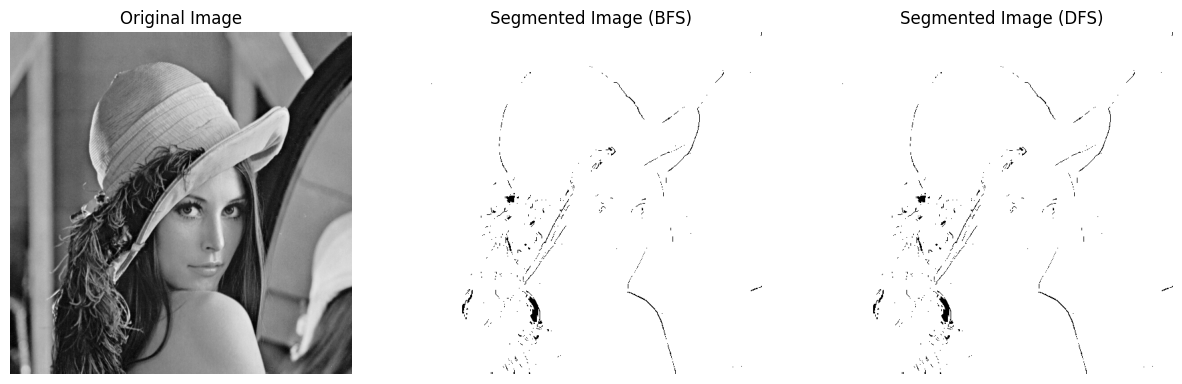

In [6]:
# 读取图像并转换为灰度图
img = cv2.imread('lena.bmp', cv2.IMREAD_GRAYSCALE)

# 设置起始点和阈值
start_point = (100, 100)  # 可根据图像选择
threshold = 15            # 根据图像对比度调整

# 分别使用BFS和DFS进行分割
segmented_mask_bfs = bfs_segmentation(img, start_point, threshold)
segmented_mask_dfs = dfs_segmentation(img, start_point, threshold)

# 显示原始图像、BFS和DFS分割结果
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_mask_bfs, cmap='gray')
plt.title('Segmented Image (BFS)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(segmented_mask_dfs, cmap='gray')
plt.title('Segmented Image (DFS)')
plt.axis('off')

plt.show()
